In [2]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join as pjoin
import os

In [4]:
def get_post_dir():
    post_dir = '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_polybin/models/galaxy'
    return post_dir


def get_all_summaries():
    """
    Get all available summary statistics.

    Returns:
        :summaries (list): List of summary statistic identifiers
    """
    post_dir = get_post_dir()
    summaries = sorted([d for d in os.listdir(post_dir) if os.path.isdir(pjoin(post_dir, d))])
    return summaries


def get_samples(summary):
    """
    Get posterior samples and true parameters for a given summary statistic.

    Parameters:
        :summary (str): The summary statistic identifier

    Returns:
        :samples_dict (dict): Dictionary of posterior samples arrays, each of shape (num_samples, num_test_points)
        :theta_true_dict (dict): Dictionary of true parameter values arrays, each of shape (num_test_points)
    """
    
    # Load samples
    post_dir = get_post_dir()
    dirname = pjoin(post_dir, summary, 'kmin-0.0_kmax-0.4')
    samples = np.load(pjoin(dirname, 'posterior_samples.npy'))
    theta_true = np.load(pjoin(dirname, 'theta_test.npy'))

    # Convert to dictionary format
    param_names = ['Omega_m', 'Omega_b', 'h', 'ns', 'sigma8', 'sigma_rad', 'sigma_tran']
    samples_dict = {name: samples[..., i] for i, name in enumerate(param_names)}
    theta_true_dict = {name: theta_true[..., i] for i, name in enumerate(param_names)}

    return samples_dict, theta_true_dict


def compute_posterior_std(samples):
    """
    Compute the posterior standard deviation for each parameter.

    Parameters:
        :samples (dict): Dictionary of posterior samples arrays

    Returns:
        :std_dict (dict): Dictionary of posterior standard deviations for each parameter
    """
    std_dict = {name: np.std(samples[name], axis=0) for name in samples}
    return std_dict

Recreate plot like Matt has

Processing summary: nbar+zPk0
Processing summary: nbar+zPk0+zPk2+zPk4
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0+zBk2
Processing summary: nbar+zPk0+zPk2+zPk4+zQk0
Processing summary: zBk0
Processing summary: zBk0+zBk2


Text(0.5, 1.0, 'Omega_m')

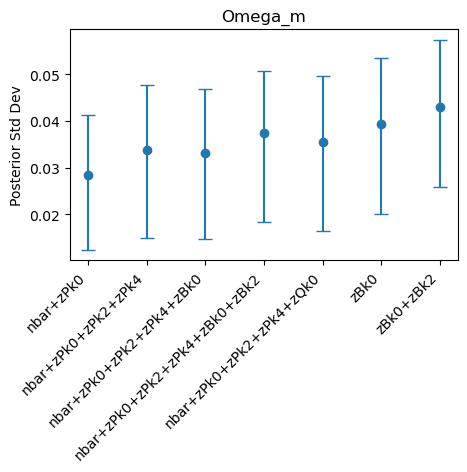

In [7]:
summaries = get_all_summaries()

all_std = []
par = 'Omega_m'

for summary in summaries:
    print(f"Processing summary: {summary}")
    samps, trues = get_samples(summary)
    std_dict = compute_posterior_std(samps)
    all_std.append(std_dict[par])

all_std = np.array(all_std)
all_std_mean = np.mean(all_std, axis=1)
all_std_upper = np.percentile(all_std, 84, axis=1)
all_std_lower = np.percentile(all_std, 16, axis=1)

# Plotting
plt.figure(figsize=(5, 3))
plt.errorbar(summaries, all_std_mean, yerr=[all_std_mean - all_std_lower, all_std_upper - all_std_mean], fmt='o', capsize=5)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'Posterior Std Dev')
plt.title(par)


Identify cases with large differences between posterior runs

In [1]:
s0 = 'nbar+zPk0'
s1 = 'nbar+zPk0+zPk2+zPk4+zBk0'
par = 'Omega_m'

samps_0, trues_0 = get_samples(s0)
std_dict_0 = compute_posterior_std(samps_0)

samps_1, trues_1 = get_samples(s1)
std_dict_1 = compute_posterior_std(samps_1)

# Find indices for which the change in std is largest
std_diff = std_dict_1[par] - std_dict_0[par]
# largest_diff_indices = np.argsort(np.abs(std_diff))[-5:]
# for idx in largest_diff_indices:
#     print(f"Test point {idx}:")
#     print(f"  True value: {trues_0[par][idx]}")
#     print(f"  Std with {s0}: {std_dict_0[par][idx]}")
#     print(f"  Std with {s1}: {std_dict_1[par][idx]}")
#     print(f"  Difference in Std: {std_diff[idx]}")
#     print()

# Plot comparison
fig, axs = plt.subplots(1, 2, figsize=(10, 4),)
axs[0].plot(trues_0[par], std_diff, '.')
m = std_diff > 0
axs[1].hist(trues_0[par][m], bins=10, alpha=0.7, label='Increased Std Dev')
axs[1].hist(trues_0[par][~m], bins=10, alpha=0.7, label='Decreased Std Dev')
axs[0].set_xlabel(f'True {par}')
axs[0].set_ylabel(f'Std Dev Difference')
axs[1].set_xlabel(f'True {par}')
axs[1].set_ylabel('Number of Test Points')
axs[1].legend()

NameError: name 'get_samples' is not defined